# Mueller price-unit prediction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Sales Data

In [2]:
sales = pd.read_csv('/Users/alp/buynomics/data/sales.csv')

In [3]:
sales.drop(columns="Unnamed: 0", inplace=True)

In [4]:
product = pd.read_csv('/Users/alp/buynomics/data/product.csv')

In [5]:
product.drop(columns="Unnamed: 0", inplace=True)

<u>Sales Dataset columns:</u> Sales data has 260 rows and 4 columns
    <br> date: The date of the sales. (object type)
    <br> product_id: Unique identifier for each product. (integer dtype)
    <br> price: The price of the product. (float dtype)
    <br> units: The number of units sold. (float dtype)

In [6]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        260 non-null    object 
 1   product_id  260 non-null    int64  
 2   price       260 non-null    float64
 3   units       260 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 8.2+ KB


In [7]:
sales

,date,product_id,price,units
0,2020-01-01,0,4.65,1126.0
1,2020-01-02,0,4.76,1205.0
2,2020-01-03,0,5.22,1007.0
3,2020-01-04,0,5.45,1282.0
4,2020-01-05,0,3.33,1037.0
...,...,...,...,...
255,2020-01-06,26,3.18,1524.0
256,2020-01-07,26,2.81,1153.0
257,2020-01-08,26,5.00,913.0
258,2020-01-09,26,3.38,1603.0


In [8]:
# Check the time range of the data
print("Min Date:", sales['date'].min())
print("Max Date:", sales['date'].max())


Min Date: 2020-01-01
Max Date: 2020-01-10


<u>Product Dataset columns:</u> Product data has 27 rows and 5 columns
    <br> brand: The brand of the product. (object dtype)
    <br> flavour (object): The flavor of the product. (object dtype)
    <br> volume_per_joghurt_g: The volume of yoghurt per unit. (int dtype)
    <br> packsize: The pack size of the product. (int dtype)
    <br> product_id: Unique identifier for each product. (int dtype)

### Product Data

In [9]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   brand                 27 non-null     object
 1   flavour               27 non-null     object
 2   volume_per_joghurt_g  27 non-null     int64 
 3   packsize              27 non-null     int64 
 4   product_id            27 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 1.2+ KB


In [10]:
product

,brand,flavour,volume_per_joghurt_g,packsize,product_id
0,Mueller,blueberry,150,6,0
1,Oikos,chocolate,1000,1,1
2,Alnatura,strawberry,1000,1,2
3,Mueller,straciatella,500,6,3
4,Danone,straciatella,150,6,4
5,Danone,strawberry,150,1,5
6,Alnatura,raspberry,500,6,6
7,Rewe,strawberry,1000,6,7
8,Alnatura,straciatella,150,6,8
9,Activia,blueberry,1000,6,9


Statistics for Each Brand: 

In [11]:
# Grouping Product Data by Brand
brand_grouped = product.groupby(['brand'])

brand_statistics = brand_grouped.agg({
    'product_id': ['count', list],
    'packsize': list,
    'volume_per_joghurt_g': list
})

brand_statistics = brand_statistics.reset_index()
brand_statistics.columns = ['brand', 'product_count', 'product_ids', 'packsizes', 'volume_per_joghurt_g']
brand_statistics


,brand,product_count,product_ids,packsizes,volume_per_joghurt_g
0,Actimel,1,[19],[6],[1000]
1,Activia,2,"[9, 23]","[6, 6]","[1000, 500]"
2,Alnatura,3,"[2, 6, 8]","[1, 6, 6]","[1000, 500, 150]"
3,Danone,5,"[4, 5, 13, 21, 25]","[6, 1, 6, 6, 1]","[150, 150, 150, 1000, 500]"
4,Ecke-Mit-Was-Drin,2,"[12, 22]","[6, 6]","[500, 1000]"
5,Ja!,2,"[11, 16]","[6, 6]","[500, 500]"
6,Mueller,4,"[0, 3, 10, 17]","[6, 6, 6, 6]","[150, 500, 1000, 150]"
7,Oikos,4,"[1, 15, 18, 26]","[1, 6, 1, 1]","[1000, 500, 1000, 500]"
8,Rewe,4,"[7, 14, 20, 24]","[6, 6, 1, 6]","[1000, 1000, 500, 1000]"


Provided Sales and Product datasets do not have any missing values.

In [12]:
# Check for missing values in both dataframes
print("Missing Values in Sales Data:")
print(sales.isnull().sum())

print("\nMissing Values in Product Data:")
print(product.isnull().sum())

Missing Values in Sales Data:
date          0
product_id    0
price         0
units         0
dtype: int64

Missing Values in Product Data:
brand                   0
flavour                 0
volume_per_joghurt_g    0
packsize                0
product_id              0
dtype: int64


#### Descriptive Statistics for Sales Data: 

Prices range from 1.46 to 9.42 with the average of 5.29. Prices have a relatively low standard deviation of 1.88, suggesting less variability.The low standard deviation indicates relatively consistent pricing across products.

The number of units sold ranges from 16 to 2170. The mean number of units sold is approximately 1177.50. Units have a standard deviation of 401.77, indicating that some products sell much more or less than the average. As it can also be seen from the boxplot below, dataset has might have an outlier observations since some points beneath the whiskers.

       product_id       price        units
count  260.000000  260.000000   260.000000
mean    12.911538    5.288538  1177.496154
std      7.846738    1.881547   401.771103
min      0.000000    1.460000    16.000000
25%      6.000000    3.965000   944.000000
50%     13.000000    5.140000  1275.500000
75%     20.000000    6.785000  1453.250000
max     26.000000    9.420000  2170.000000


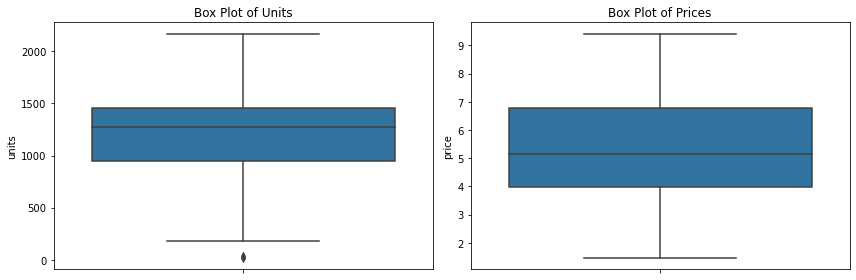

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print(sales.describe())
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Box Plot for Units
sns.boxplot(data=sales, y='units', ax=axes[0])
axes[0].set_title('Box Plot of Units')

# Box Plot for Prices
sns.boxplot(data=sales, y='price', ax=axes[1])
axes[1].set_title('Box Plot of Prices')
plt.tight_layout()
plt.show()


#### Units and Price relationship
The scatter plots show individual data points for each observation in the dataset. Notably, the scatter plot for 'price' and 'units' reveals a clear decreasing trend. As the price of the product increases, there is a visible trend where the number of units sold tends to decrease. This decreasing trend aligns with the negative correlation coefficient (-0.70) observed in the correlation heatmap. The negative correlation suggests an inverse relationship, and the pair plot visually confirms this pattern. Of course, product_id column does not provide any meaningful information for this case. Therefore there is no need to focus on id column on that part.

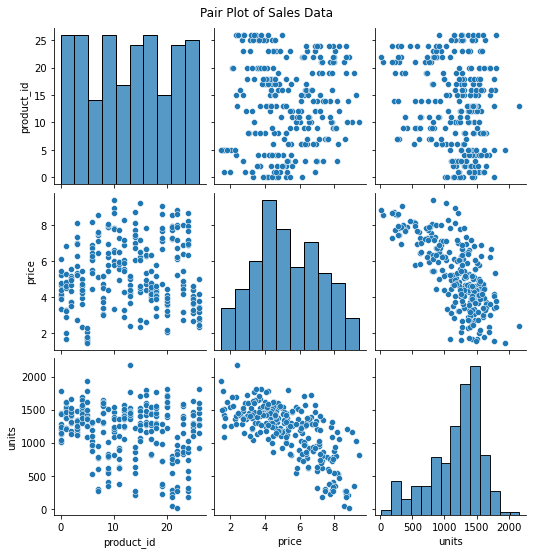

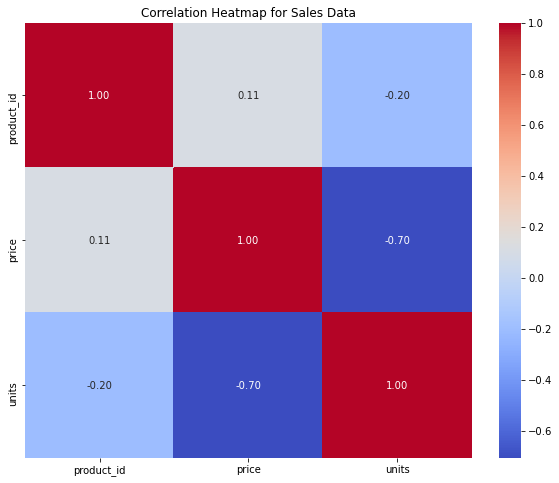

In [14]:
# Pair Plot for Sales Data
sns.pairplot(sales)
plt.suptitle("Pair Plot of Sales Data", y=1.02)
plt.show()

#Heatmap for Correlation in Sales Data
plt.figure(figsize=(10, 8))
sns.heatmap(sales.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Sales Data')
plt.show()

##### Descriptive Statistics for Numerical columns for each dataset

#### Descriptive Statistics for Product Data: 

The volumes range from a minimum of 150 grams to a maximum of 1000 grams.The most common volume, represented by the median, is 500 grams.

There are 2 packsizes and the most common pack size is "6" as we see it from the median value

In [15]:
print(product.describe())


       volume_per_joghurt_g   packsize  product_id
count             27.000000  27.000000   27.000000
mean             625.925926   4.703704   13.000000
std              342.886607   2.232880    7.937254
min              150.000000   1.000000    0.000000
25%              500.000000   3.500000    6.500000
50%              500.000000   6.000000   13.000000
75%             1000.000000   6.000000   19.500000
max             1000.000000   6.000000   26.000000


Negative correlation between Price and Units

### Merging Sales and Product datasets

Sales and Product datasets are merged with product_id column. Now we have one dataset with 8 columns and 260 rows for the following analysis and modelling sections. 

In [16]:
merged_data = pd.merge(sales, product, on='product_id')
merged_data

,date,product_id,price,units,brand,flavour,volume_per_joghurt_g,packsize
0,2020-01-01,0,4.65,1126.0,Mueller,blueberry,150,6
1,2020-01-02,0,4.76,1205.0,Mueller,blueberry,150,6
2,2020-01-03,0,5.22,1007.0,Mueller,blueberry,150,6
3,2020-01-04,0,5.45,1282.0,Mueller,blueberry,150,6
4,2020-01-05,0,3.33,1037.0,Mueller,blueberry,150,6
...,...,...,...,...,...,...,...,...
255,2020-01-06,26,3.18,1524.0,Oikos,strawberry,500,1
256,2020-01-07,26,2.81,1153.0,Oikos,strawberry,500,1
257,2020-01-08,26,5.00,913.0,Oikos,strawberry,500,1
258,2020-01-09,26,3.38,1603.0,Oikos,strawberry,500,1


#### Scatter Plot Analysis for Price vs. Units by Brand

The scatter plot displays individual data points, where each point represents a product with its corresponding 'price' and 'units' values. Different brands are distinguished by color (hue) for easy identification. Across all brands, there is a noticeable decreasing trend, indicating that as the price of a product increases, the number of units sold tends to decrease. This aligns with the negative correlation observed in the previous analysis.

Brand 'Mueller' (blue colored observations) stands out as an exception to the general trend, showing a relatively better performance in unit sales even with increasing prices. This brand-specific behavior might be influenced by unique brand characteristics, customer loyalty, or specific marketing strategies.


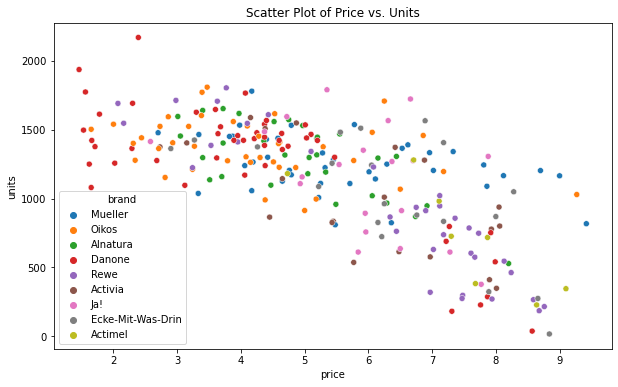

In [17]:
# Visualizing the relationship between price and units
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_data, x='price', y='units', hue='brand')
plt.title('Scatter Plot of Price vs. Units')
plt.show()

#### Time Series Analysis of Unit Sales Over a 10-Day Period

The time series analysis focuses on the unit sales over a 10-day period. Notable fluctuations in unit sales are observed during this timeframe.The left subplot displays the total units sold over time for all brands combined.From 01.01 to 03.01, there is a decreasing trend in total unit sales. A peak in sales is observed on 04.01, followed by a decrease on 05.01. Another increase in unit sales occurs between 05.01-08.01, followed by a subsequent decrease. The sharp decrease in sales on 10.01 is notable.

The right subplot breaks down unit sales over time for each brand individually.Brands Danone, Okikos, and Mueller consistently have the highest unit sales throughout the 10 days. Brands Actimel, Activia, and Ecke-Mit-Was-Drin have relatively lower unit sales. Actimel has no sales data recorded on 09.01 and 10.01.


Understanding the daily fluctuations in unit sales is crucial for inventory management, marketing, and strategic decision-making. Identifying brands with consistent high sales (Danone, Okikos, Mueller) and those with lower sales (Actimel, Activia, Ecke-Mit-Was-Drin) helps in optimizing marketing efforts and product positioning. The absence of sales data for Actimel on 09.01 and 10.01 may require further investigation, ensuring data completeness and accuracy.

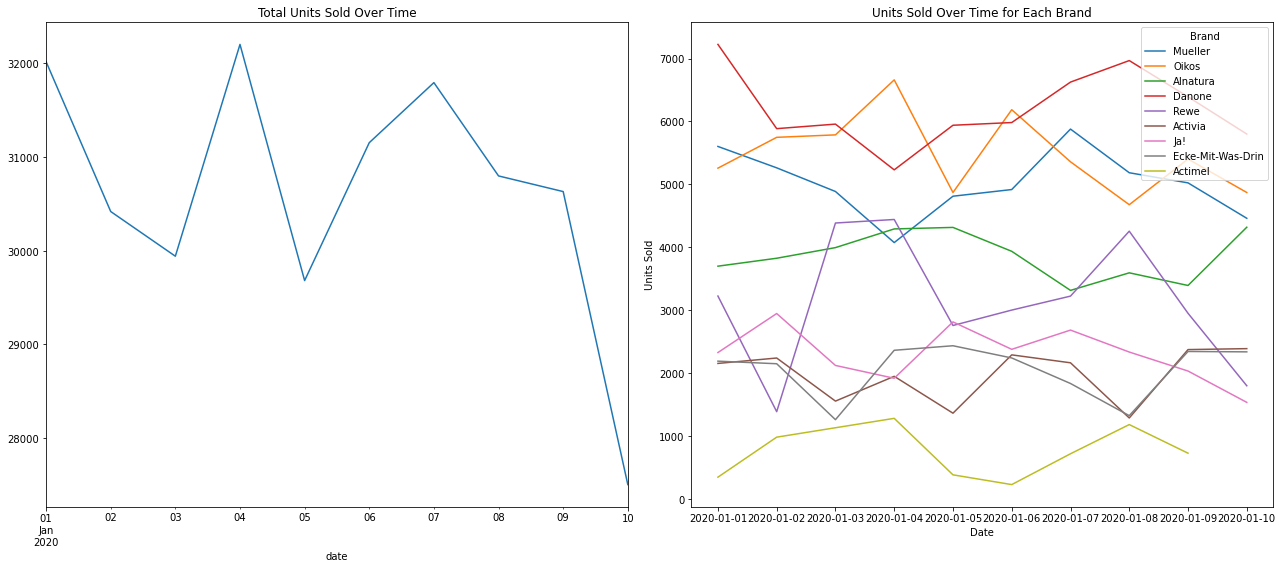

Number of products for each brand:


Danone               5
Rewe                 4
Mueller              4
Oikos                4
Alnatura             3
Ecke-Mit-Was-Drin    2
Ja!                  2
Activia              2
Actimel              1
Name: brand, dtype: int64

In [18]:
# Time Series Analysis
plt.figure(figsize=(18, 8))

# Plotting Total Units Sold Over Time
plt.subplot(1, 2, 1)
merged_data['date'] = pd.to_datetime(merged_data['date'])
daily_units_total = merged_data.groupby('date')['units'].sum()
daily_units_total.plot()
plt.title('Total Units Sold Over Time')

# Plotting Units Sold Over Time for Each Brand
plt.subplot(1, 2, 2)
merged_data['date'] = pd.to_datetime(merged_data['date'])
brands = merged_data['brand'].unique()

for brand in brands:
    brand_data = merged_data[merged_data['brand'] == brand]
    daily_units_brand = brand_data.groupby('date')['units'].sum()
    plt.plot(daily_units_brand, label=brand)

plt.title('Units Sold Over Time for Each Brand')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend(title='Brand')

plt.tight_layout()
plt.show()

print("Number of products for each brand:")
product.brand.value_counts()

Danone has 5 products, Mueller has 4 products, and Oikos has 4 products, showcasing a correlation between the number of products and high unit sales. Brands with a higher variety of products may have a broader appeal to consumers, contributing to increased unit sales.

In [19]:
product.brand.value_counts()

Danone               5
Rewe                 4
Mueller              4
Oikos                4
Alnatura             3
Ecke-Mit-Was-Drin    2
Ja!                  2
Activia              2
Actimel              1
Name: brand, dtype: int64

In [20]:
# Average prices for each brand
grouped_stats = merged_data.groupby('brand').agg({'price': 'mean', 'units': 'sum'})
print(grouped_stats)

                     price    units
brand                              
Actimel            7.39250   5839.0
Activia            5.89900  19755.0
Alnatura           4.93700  38676.0
Danone             4.21500  61999.0
Ecke-Mit-Was-Drin  6.34300  20469.0
Ja!                5.90550  23083.0
Mueller            5.59125  50097.0
Oikos              4.21825  54812.0
Rewe               6.18000  31419.0


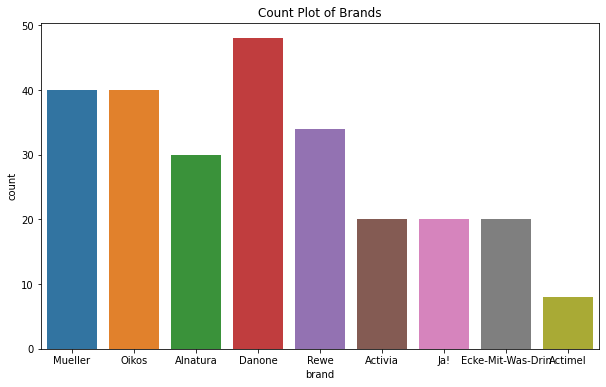

In [21]:
# Categorical Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_data, x='brand')
plt.title('Count Plot of Brands')
plt.show()

The ANOVA test indicates a statistically significant difference in unit sales among at least one pair of brands (p-value < 0.05). The Tukey post-hoc test further reveals specific brand pairs with significant differences in mean unit sales. For example, Oikos and Actimel, Actimel and Danone,Activia and Oikos, Danone and Rewe, Mueller and Rewe show significant differences, suggesting variations in consumer purchasing behavior between these brands.

In [22]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ANOVA test for significant differences in unit sales among different brands
anova_result = f_oneway(*[group['units'] for name, group in merged_data.groupby('brand')])
print("ANOVA p-value:", anova_result.pvalue)

# Tukey post-hoc test for pairwise brand comparisons
tukey_result = pairwise_tukeyhsd(merged_data['units'], merged_data['brand'])
print("Tukey Post-hoc Test Results:\n", tukey_result)


ANOVA p-value: 1.9110319298311418e-08
Tukey Post-hoc Test Results:
               Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1            group2       meandiff p-adj    lower     upper   reject
-------------------------------------------------------------------------------
          Actimel           Activia   257.875 0.7352 -224.6288  740.3788  False
          Actimel          Alnatura   559.325 0.0053  100.3723 1018.2777   True
          Actimel            Danone  561.7708 0.0028  121.3071 1002.2345   True
          Actimel Ecke-Mit-Was-Drin   293.575 0.5962 -188.9288  776.0788  False
          Actimel               Ja!   424.275 0.1352  -58.2288  906.7788  False
          Actimel           Mueller    522.55 0.0092   75.8383  969.2617   True
          Actimel             Oikos   640.425  0.001  193.7133 1087.1367   True
          Actimel              Rewe  194.2132    0.9 -259.0202  647.4466  False
          Activia          Alnatura    301.45 0.1113

In [23]:
merged_data

,date,product_id,price,units,brand,flavour,volume_per_joghurt_g,packsize
0,2020-01-01,0,4.65,1126.0,Mueller,blueberry,150,6
1,2020-01-02,0,4.76,1205.0,Mueller,blueberry,150,6
2,2020-01-03,0,5.22,1007.0,Mueller,blueberry,150,6
3,2020-01-04,0,5.45,1282.0,Mueller,blueberry,150,6
4,2020-01-05,0,3.33,1037.0,Mueller,blueberry,150,6
...,...,...,...,...,...,...,...,...
255,2020-01-06,26,3.18,1524.0,Oikos,strawberry,500,1
256,2020-01-07,26,2.81,1153.0,Oikos,strawberry,500,1
257,2020-01-08,26,5.00,913.0,Oikos,strawberry,500,1
258,2020-01-09,26,3.38,1603.0,Oikos,strawberry,500,1


#### Correlation Heatmap Analysis
As mentioned before, strong negative correlation between price and units (-0.70) is a crucial insight, indicating a clear inverse relationship. Businesses should carefully consider the impact of pricing on unit sales.The positive correlation between packsize and price (0.56) is noteworthy for pricing strategies, suggesting that larger pack sizes are associated with higher prices. The negative correlation between packsize and units (-0.36) and volume_per_joghurt_g and units (-0.49) provides insights into customer preferences regarding product sizes.


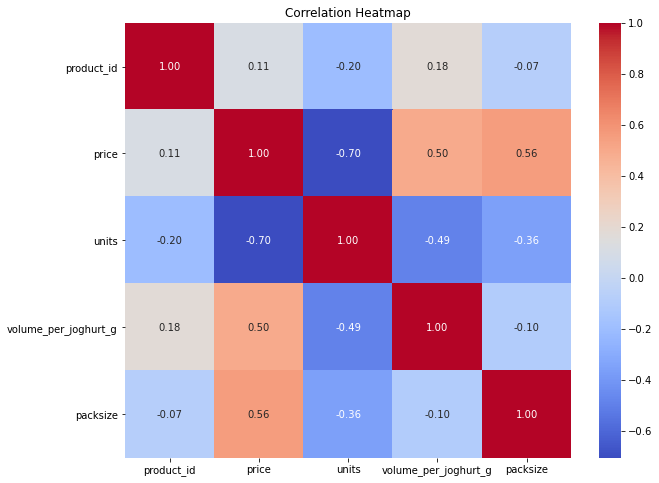

In [24]:
#Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(merged_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Descriptive Statistics

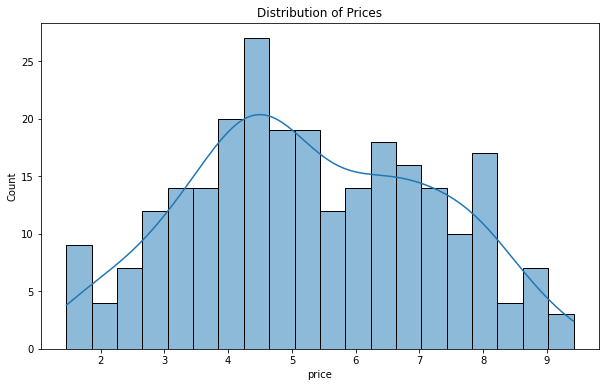

In [25]:
#Distribution Plot of Price
plt.figure(figsize=(10, 6))
sns.histplot(merged_data['price'], bins=20, kde=True)
plt.title('Distribution of Prices')
plt.show()

#### Summary Statistics for Units by Brand
Mueller has the lowest standard deviation compared to other brands, which means unit sales are the most consistent for Mueller compared to other brands. Whereas the Danone has the second highest standard deviation score among the brands which means it might contain more outliers or unstable unit sales compared to others. It can also be seen from the boxplot with points outside of the whiskers. However, Danone also has the second highest mean value which shows that Danone is the second brand which makes the biggest unit sales after Oikos. 



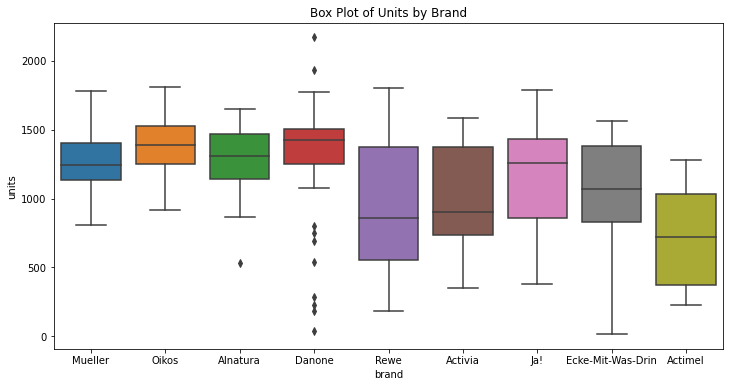

                   count         mean         std    min      25%     50%  \
brand                                                                       
Actimel              8.0   729.875000  394.864330  227.0   372.75   721.5   
Activia             20.0   987.750000  392.645263  348.0   737.00   901.5   
Alnatura            30.0  1289.200000  266.773105  528.0  1141.75  1311.0   
Danone              48.0  1291.645833  444.891308   37.0  1247.25  1422.0   
Ecke-Mit-Was-Drin   20.0  1023.450000  439.815090   16.0   832.00  1068.0   
Ja!                 20.0  1154.150000  404.984766  377.0   859.00  1258.0   
Mueller             40.0  1252.425000  206.108869  809.0  1138.00  1241.5   
Oikos               40.0  1370.300000  210.465443  913.0  1254.00  1389.5   
Rewe                34.0   924.088235  508.762037  185.0   552.25   861.5   

                       75%     max  
brand                               
Actimel            1031.00  1280.0  
Activia            1372.75  1588.0  
Alna

In [26]:
#Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_data, x='brand', y='units')
plt.title('Box Plot of Units by Brand')
plt.show()

# Summary statistics for units by brand
brand_summary_stats = merged_data.groupby('brand')['units'].describe()
print(brand_summary_stats)

### Price Elastisicty Analysis before modelling

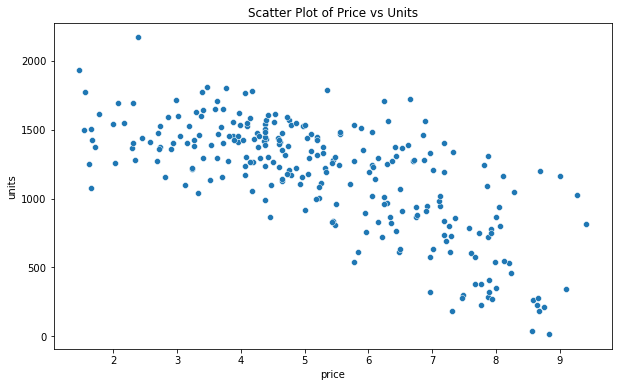

In [27]:
# Scatter plot of 'price' vs 'units'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='units', data=merged_data)
plt.title('Scatter Plot of Price vs Units')
plt.show()


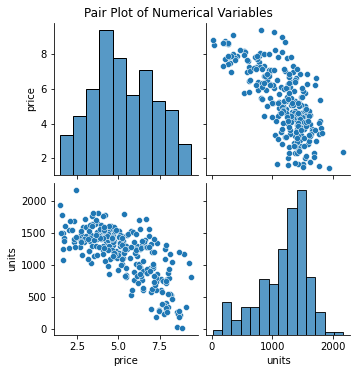

In [28]:
sns.pairplot(merged_data[['price', 'units']])
plt.suptitle("Pair Plot of Numerical Variables", y=1.02)
plt.show()


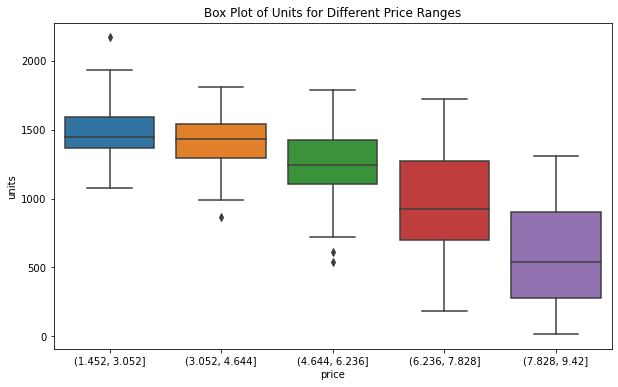

,count,mean,std,min,25%,50%,75%,max
price,,,,,,,,
"(1.452, 3.052]",32.0,1485.687500,220.360473,1080.0,1363.75,1447.5,1594.5,2170.0
"(3.052, 4.644]",75.0,1420.413333,195.968220,865.0,1296.00,1430.0,1543.0,1809.0
"(4.644, 6.236]",64.0,1222.718750,258.215086,536.0,1108.75,1245.0,1425.5,1790.0
"(6.236, 7.828]",58.0,946.000000,382.553838,181.0,698.25,924.0,1273.5,1723.0
"(7.828, 9.42]",31.0,611.419355,377.726954,16.0,280.00,540.0,903.5,1306.0


In [29]:
# Box plot to visualize the distribution of units for different price ranges
plt.figure(figsize=(10, 6))
sns.boxplot(x=pd.cut(merged_data['price'], bins=5), y='units', data=merged_data)
plt.title('Box Plot of Units for Different Price Ranges')
plt.show()

price_range_statistics = merged_data.groupby(pd.cut(merged_data['price'], bins=5))['units'].describe()
price_range_statistics



In [30]:
# Calculate summary statistics directly without creating a new column
price_range_statistics = merged_data.groupby(pd.cut(merged_data['price'], bins=5))['units'].describe()

# Print the summary statistics
print(price_range_statistics)


                count         mean         std     min      25%     50%  \
price                                                                     
(1.452, 3.052]   32.0  1485.687500  220.360473  1080.0  1363.75  1447.5   
(3.052, 4.644]   75.0  1420.413333  195.968220   865.0  1296.00  1430.0   
(4.644, 6.236]   64.0  1222.718750  258.215086   536.0  1108.75  1245.0   
(6.236, 7.828]   58.0   946.000000  382.553838   181.0   698.25   924.0   
(7.828, 9.42]    31.0   611.419355  377.726954    16.0   280.00   540.0   

                   75%     max  
price                           
(1.452, 3.052]  1594.5  2170.0  
(3.052, 4.644]  1543.0  1809.0  
(4.644, 6.236]  1425.5  1790.0  
(6.236, 7.828]  1273.5  1723.0  
(7.828, 9.42]    903.5  1306.0  


percentage_change_price calculates the average percentage change in price from the previous observation. and percentage_change_units calculates the average percentage change in units sold from the previous observation.
preliminary_elasticity Calculates the preliminary price elasticity, which is the ratio of the average percentage change in units to the average percentage change in price.

In [31]:
# Preliminary calculation of percentage changes in price and units
percentage_change_price = ((merged_data['price'] - merged_data['price'].shift(1)) / merged_data['price'].shift(1)).mean()
percentage_change_units = ((merged_data['units'] - merged_data['units'].shift(1)) / merged_data['units'].shift(1)).mean()

# Preliminary calculation of price elasticity
preliminary_elasticity = percentage_change_units / percentage_change_price

print(f"Preliminary Price Elasticity: {preliminary_elasticity}")


Preliminary Price Elasticity: 6.2846458909338905


### Modeling

#### Linear Regression

The Mean Squared Error (MSE) for our Linear regression model is approximately 55448.32, indicating the average squared difference between predicted and actual unit values. Comparing this to the Baseline Mean Squared Error of 214884.92, Linear regression model demonstrates an improvement over a simplistic baseline that predicts the mean units for all instances, showcasing its efficacy in capturing the relationship between prices and units sold. Additionally, the R-squared score of 0.72 suggests that approximately 72% of the variance in units sold can be explained by Linear model, further supporting its effectiveness in capturing the relationship between prices and units sold."

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score



In [33]:
X = merged_data[['price', 'brand', 'flavour', 'volume_per_joghurt_g', 'packsize']]
y = merged_data['units']

# Encode categorical variables
X_encoded = pd.get_dummies(X, columns=['brand', 'flavour'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [34]:
linear_regression_model = LinearRegression()

linear_regression_model.fit(X_train, y_train)

y_pred = linear_regression_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Compare against baseline (e.g., predicting mean units)
baseline_prediction = y_train.mean()
baseline_mse = mean_squared_error(y_test, [baseline_prediction] * len(y_test))
print(f"Baseline Mean Squared Error: {baseline_mse}")

r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

Mean Squared Error: 55448.317882766896
Baseline Mean Squared Error: 214884.9201414571
R-squared: 0.7169951187478016



The scatter plot illustrates the relationship between the actual and predicted unit sales. Points close to the diagonal line indicate accurate predictions, while deviations, especially for lower unit values, suggest areas for potential model improvement.

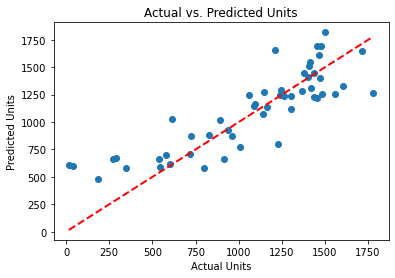

In [35]:
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)  # Adding the diagonal line
plt.xlabel("Actual Units")
plt.ylabel("Predicted Units")
plt.title("Actual vs. Predicted Units")
plt.show()



The coefficients in the linear regression model indicate the magnitude and direction of the impact each feature has on the predicted units. "flavour_chocolate" and "flavour_straciatella" have relatively high positive coefficients, suggesting a significant positive impact on predicted units. Similarly, "price" has a large negative coefficient, indicating a substantial negative impact on predicted units.

In [36]:
coefficients = pd.DataFrame({'feature': X_encoded.columns, 'coefficient': linear_regression_model.coef_})
print(coefficients)


                    feature  coefficient
0                     price  -102.736574
1      volume_per_joghurt_g    -0.084287
2                  packsize   -30.236163
3             brand_Activia  -107.117400
4            brand_Alnatura   115.743912
5              brand_Danone   -11.065934
6   brand_Ecke-Mit-Was-Drin    50.052399
7                 brand_Ja!    67.374838
8             brand_Mueller   107.711116
9               brand_Oikos   -12.533330
10               brand_Rewe   -89.536759
11        flavour_chocolate   332.082719
12        flavour_raspberry   -54.616481
13     flavour_straciatella   301.622545
14       flavour_strawberry   -25.800787


In [37]:
cv_scores_lr = cross_val_score(linear_regression_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Calculate the mean squared error from cross-validation scores
cv_mse_lr = -cv_scores_lr.mean()

# Print the result
print(f"Cross-Validation Mean Squared Error (Linear Regression): {cv_mse_lr}")

Cross-Validation Mean Squared Error (Linear Regression): 58973.60488346629


The red dashed line represents zero residuals. In areas below the line, the model tends to underestimate units, and above the line, it tends to overestimate. The visual aids in identifying where the model performs well and areas where improvements might be needed.

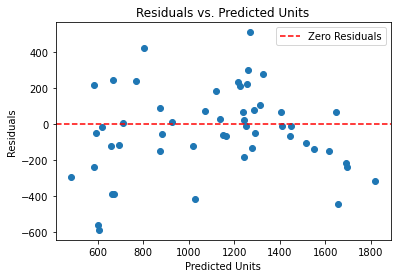

In [38]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.xlabel("Predicted Units")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Units")
plt.legend()
plt.show()


#### Random Forest

The Random Forest model outperformed the Linear Regression model on the test set, as evidenced by a lower Mean Squared Error (43,370 compared to 55,448). Both models performed better than the baseline model, indicating some predictive capability. The R-squared value for the Random Forest model (0.78) suggests a better fit to the data compared to the Linear Regression model (0.72). These results suggest that the Random Forest model provides a more accurate prediction of units based on prices and product attributes.


In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Mean Squared Error (Random Forest) on Test Set: {mse_rf}")

# Compare against baseline (e.g., predicting mean units)
baseline_prediction_rf = y_train.mean()
baseline_mse_rf = mean_squared_error(y_test, [baseline_prediction_rf] * len(y_test))
print(f"Baseline Mean Squared Error (Random Forest) on Test Set: {baseline_mse_rf}")

# R-squared for Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
print(f"R-squared (Random Forest): {r2_rf}")


Mean Squared Error (Random Forest) on Test Set: 43370.11575440705
Baseline Mean Squared Error (Random Forest) on Test Set: 214884.9201414571
R-squared (Random Forest): 0.7786415363416325


In [40]:
# Cross-validation Mean Squared Error on the training set
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_mse_rf = -cv_scores_rf.mean()
print(f"Cross-Validation Mean Squared Error (Random Forest): {cv_mse_rf}")


Cross-Validation Mean Squared Error (Random Forest): 61910.32705259144


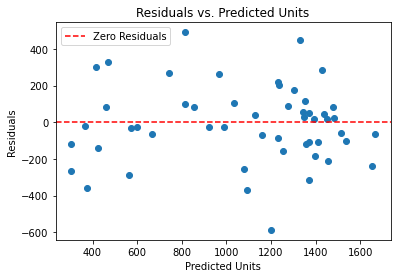

In [41]:
residuals = y_test - y_pred_rf
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.xlabel("Predicted Units")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Units")
plt.legend()
plt.show()


In Random Forest, the most influential feature is 'price' with an importance score of approximately 75%, indicating that it has the highest impact on predicting unit sales

Comparatively, Random Forest considers a broader set of features and their non-linear interactions, while Linear Regression highlights individual feature contributions linearly.

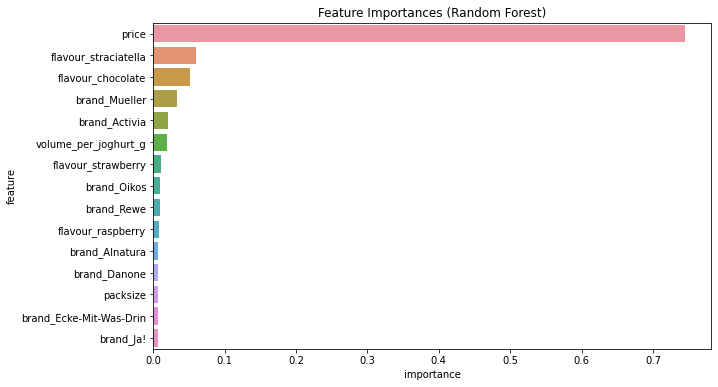

                    feature  importance
0                     price    0.744653
1      volume_per_joghurt_g    0.019701
2                  packsize    0.006746
3             brand_Activia    0.020953
4            brand_Alnatura    0.006874
5              brand_Danone    0.006846
6   brand_Ecke-Mit-Was-Drin    0.006666
7                 brand_Ja!    0.006482
8             brand_Mueller    0.033335
9               brand_Oikos    0.009922
10               brand_Rewe    0.009149
11        flavour_chocolate    0.051167
12        flavour_raspberry    0.007406
13     flavour_straciatella    0.059873
14       flavour_strawberry    0.010225


In [42]:
feature_importances_rf = pd.DataFrame({'feature': X_train.columns, 'importance': rf_model.feature_importances_})
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances_rf.sort_values(by='importance', ascending=False))
plt.title('Feature Importances (Random Forest)')
plt.show()

print(feature_importances_rf)

#### Hyperparameter Tuning - Improvement of Random forest Model

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

# Get the best model
best_rf_model = grid_search.best_estimator_


Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


Mean Squared Error (Best Random Forest) on Test Set: 36866.51733780552
Baseline Mean Squared Error (Best Random Forest) on Test Set: 214884.9201414571
R-squared (Best Random Forest) on Test Set: 0.8118355117025033


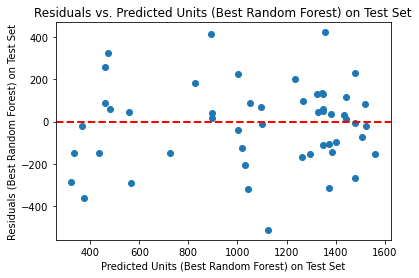

Feature Importances (Best Random Forest):
                    feature  importance
0                     price    0.760032
1      volume_per_joghurt_g    0.013428
2                  packsize    0.004478
3             brand_Activia    0.021488
4            brand_Alnatura    0.005079
5              brand_Danone    0.004005
6   brand_Ecke-Mit-Was-Drin    0.003991
7                 brand_Ja!    0.004144
8             brand_Mueller    0.033740
9               brand_Oikos    0.007626
10               brand_Rewe    0.005730
11        flavour_chocolate    0.059578
12        flavour_raspberry    0.005554
13     flavour_straciatella    0.065301
14       flavour_strawberry    0.005826


In [44]:
# Use the best model to make predictions on the test set
y_pred_best_rf = best_rf_model.predict(X_test)

# Evaluate the performance of the best model on the test set
mse_best_rf_test = mean_squared_error(y_test, y_pred_best_rf)
print(f"Mean Squared Error (Best Random Forest) on Test Set: {mse_best_rf_test}")

# Compare against baseline (e.g., predicting mean units) on the test set
baseline_prediction_best_rf_test = y_train.mean()
baseline_mse_best_rf_test = mean_squared_error(y_test, [baseline_prediction_best_rf_test] * len(y_test))
print(f"Baseline Mean Squared Error (Best Random Forest) on Test Set: {baseline_mse_best_rf_test}")

# R-squared for the best Random Forest model on the test set
r2_best_rf_test = r2_score(y_test, y_pred_best_rf)
print(f"R-squared (Best Random Forest) on Test Set: {r2_best_rf_test}")

# Residuals vs. Predicted Units for the best Random Forest model on the test set
residuals_best_rf_test = y_test - y_pred_best_rf
plt.scatter(y_pred_best_rf, residuals_best_rf_test)
plt.axhline(0, color='red', linestyle='--', linewidth=2)  # Add a horizontal line at y=0
plt.xlabel("Predicted Units (Best Random Forest) on Test Set")
plt.ylabel("Residuals (Best Random Forest) on Test Set")
plt.title("Residuals vs. Predicted Units (Best Random Forest) on Test Set")
plt.show()

# Feature Importances for the best Random Forest model
feature_importance_best_rf = pd.DataFrame({'feature': X_test.columns, 'importance': best_rf_model.feature_importances_})
print("Feature Importances (Best Random Forest):")
print(feature_importance_best_rf)


Summary:

- The Random Forest model, especially after hyperparameter tuning, demonstrates superior predictive performance compared to linear regression.

- Price is identified as the most critical factor influencing unit sales, emphasizing its strategic importance in pricing decisions.

- The model provides actionable insights into the relative importance of different product attributes, aiding the client in optimizing their pricing strategy.

Further Analysis and Possible improvements:

- Explore the possibility of segmenting the market based on customer demographics, geographic locations, or other relevant factors. This could reveal nuanced patterns in price sensitivity.

- Investigate how temporal factors such as seasonality and trends impact the relationship between prices and unit sales. This can inform pricing strategies for different periods.
